Files originally from https://github.com/LucasSilvaFerreira/Perturb_Loader


In [1]:
import mudata as md
import anndata as ad
import numpy as np
import pandas as pd
import perturbvi
import seaborn as sns
import scanpy as sc
import os
import scipy
import pyro
from scipy.stats import norm
import matplotlib.pyplot as plt
import torch

smoke_test = True
subsample_frac = 1.0
downsample_frac = 1.0

# selected_guides = ["ACTG1_TSS|1", "ACTG1_TSS|2", "ACTB_TSS|1", "ACTB_TSS|2"]
# selected_genes = ["ACTG1"]
# selected_guides = ["TMED10_TSS|1", "TMED10_TSS|2"]
# selected_genes = ["TMED10"]
# selected_guides = ["KRT18_TSS|1", "KRT18_TSS|2"]
# selected_genes = ["KRT18"]
selected_genes = ["ACTB","ACTG1","KRT18"]
data_dir = "../../../Data/gasperini_pilot"


/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global seed set to 0


In [2]:
# load sceptre list of genes/guides


In [3]:
sceptre_df = pd.read_csv(f"{data_dir}/sceptre_results-2023_01_13.csv")
sceptre_df = sceptre_df.rename(columns={"gRNA_id": "guide", "gene_id": "gene", "z_value":"SCEPTRE_z_value","p_value":"SCEPTRE_p_value"})
if not smoke_test:
    selected_genes = sceptre_df["gene"].unique()
selected_guides = sceptre_df["guide"].unique()

print(len(selected_genes), len(selected_guides))
# sceptre_df.query("guide=='GATA2_TSS|1'")


3 1243


In [4]:
def construct_mudata(data_dir="."):
    rna_adata = ad.read_h5ad(f"{data_dir}/ann_exp.h5ad")
    rna_adata.obs["library_size"] = rna_adata.X.sum(axis=1)
    # rna_adata.obs["size_factor"] = rna_adata.obs["library_size"]
    rna_adata.varm["element_tested"] = ad.read_h5ad(f"{data_dir}/ann_Element_x_tested_genes.h5ad").to_df().T
    # sc.pp.filter_genes(rna_adata, min_cells=len(rna_adata)*0.1) # need genes where at least 10% of cells with nonzero counts
    grna_adata = ad.read_h5ad(f"{data_dir}/ann_guide.h5ad")
    grna_adata.varm["element_targeted"] = ad.read_h5ad(f"{data_dir}/ann_Element_guide.h5ad").to_df().T
    assert (rna_adata.varm["element_tested"].columns == grna_adata.varm["element_targeted"].columns).all()
    mdata = md.MuData({"rna": rna_adata, "grna": grna_adata})
    return mdata


force = True
mudata_file = "gasperini_pilot_highMOI.h5mu"
if mudata_file not in os.listdir(data_dir) or force:
    mdata = construct_mudata(data_dir)
else:
    mdata = md.read_h5mu(os.path.join(data_dir, mudata_file))

# mdata.raw=mdata.copy()
total_umis = mdata.mod['rna'].X.sum()
print('total depth', total_umis/1e6, 'million UMI counts')

# downsample UMIS (w/ replacement)
# counts_tensor=torch.tensor(mdata.mod['rna'].X.todense(), dtype=torch.int64)
# counts_sampler=torch.distributions.Binomial(counts_tensor, probs=torch.tensor(downsample_frac))
# counts_sampled=counts_sampler.sample((1,))
# mdata['rna'].X =scipy.sparse.csr_array(counts_sampled[0, ...].cpu().numpy())
# # mdata['rna'].X = scipy.sparse.csr_matrix(counts_sampled)
# downsample_umis = int(mdata['rna'].X.sum())
# print('subsampled depth', downsample_umis/1e6, 'million UMI counts', )
# mdata.update()

total depth 717.674112 million UMI counts


In [5]:
# guides = mdata["grna"].var_names
# # selected_guides = list(guides[guides.str.contains(r"TSS|random|scrambled", regex=True)])

# elements = list({guide.split("|")[0] for guide in selected_guides})
# selected_elements = [e for e in elements if e in mdata["grna"].varm["element_targeted"].columns]
# element_subset = mdata["grna"].varm["element_targeted"][selected_elements].copy()

# grna_subset = mdata["grna"]
# grna_subset.varm["element_targeted"] = element_subset

# grna_subset = mdata["grna"][:, selected_guides]
# # genes = list(sorted({e.split("_")[0] for e in selected_elements if "_TSS" in e}))
# # subset_genes = [g for g in genes if g in mdata["rna"].var_names]
# # print(selected_genes)

# if smoke_test:
#     selected_genes = [test_gene]  # DANGER SINGLE GENE ONLY
# assert grna_subset.varm["element_targeted"].shape == (len(selected_guides), len(selected_elements))
mdata.mod['grna'] = mdata.mod['grna'][:,selected_guides]
mdata.mod['rna'] = mdata.mod['rna'][:,selected_genes]
mdata.mod['rna'].X.sum()

1489916.0

In [6]:
guide_obs = mdata["grna"][:, selected_guides].X.sum(axis=1).copy().astype(bool)
guide_obs_idx = np.where(guide_obs)[0]
discard_cells = np.random.choice(guide_obs_idx, size=int(guide_obs.sum()*(1-subsample_frac)), replace=False)
subset_idx = [i for i in range(len(mdata)) if i not in discard_cells]
print("discarded", len(discard_cells), "cells with guide")
mdata.update()
mdata=mdata[subset_idx,:].copy()
mdata
# mdata.mod['rna']
# rna_downsample = sc.pp.downsample_counts(mdata.mod['rna'], total_counts = 1e8)


discarded 0 cells with guide


MuData object with n_obs × n_vars = 47964 × 1246
  2 modalities
    rna:	47964 x 3
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 1243
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [7]:
mdata["rna"].obs['percent_mito']

AAACCTGAGCGAGAAA    0.035365
AAACCTGAGCTGTCTA    0.027356
AAACCTGAGTTATCGC    0.049800
AAACCTGAGTTCCACA    0.032975
AAACCTGCAAATACAG    0.022816
                      ...   
TTTGTCAGTGTTTGTG    0.044018
TTTGTCATCACAAACC    0.042441
TTTGTCATCAGAGGTG    0.034075
TTTGTCATCGCGATCG    0.036911
TTTGTCATCTGGCGTG    0.046777
Name: percent_mito, Length: 47964, dtype: float32

In [8]:
# rna_subset = mdata["rna"]
# rna_subset.varm["element_tested"] = rna_subset.varm["element_tested"][selected_elements].copy()
# rna_subset = rna_subset[:, selected_genes]
# mdata_subset = md.MuData({"rna": rna_subset.copy(), "grna": grna_subset.copy()})
# assert (
#     mdata_subset["rna"].varm["element_tested"].columns == mdata_subset["grna"].varm["element_targeted"].columns
# ).all()
# mdata_subset


In [9]:
perturbvi.PERTURBVI.setup_mudata(
    mdata,
    batch_key="bath_number",
    library_size_key="library_size",
    # size_factor_key="library_size",
    var_by_element_key="element_tested",
    perturb_by_element_key="element_targeted",
    continuous_covariates_keys=["percent_mito"],
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbvi.PERTURBVI(mdata, likelihood='nb', fit_lib_size=True)
model.view_anndata_setup()


INFO     Using column names from columns of adata.varm['element_tested']                                           
INFO     Using column names from columns of adata.varm['element_targeted']                                         


Anndata setup with scvi-tools version 0.20.1.

Setup via `PERTURBVI.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'perturbation_layer': None,
│   'batch_key': 'bath_number',
│   'var_by_element_key': 'element_tested',
│   'perturb_by_element_key': 'element_targeted',
│   'library_size_key': 'library_size',
│   'size_factor_key': None,
│   'continuous_covariates_keys': ['percent_mito'],
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'}
}

        Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch         │   6   │
│         n_cells         │ 47964 │
│ n_extra_continuous_covs │   1   │
│     n_perturbations     │ 1243  │
│   n_targeted_elements   │ 1561  │
│    n_tested_elements    │ 1561  │
│         n_vars          │   3   │
└─────────────────────────┴───────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │      adata.mod['grna'].varm['element_targeted']      │
│    tested_elements    │       adata.mod['rna'].varm['element_tested']        │
└───────────────────────┴──────────────────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['bath_number'] │     1      │          0          │
│                          │     2      │          1          │
│                          │     3      │          2          │
│                          │     4      │          3          │
│                          │     5      │          4          │
│                          │     6      │          5          │
└──────────────────────────┴────────────┴─────────────────────┘

 extra_continuous_covs State 
          Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['percent_mito'] │
└───────────────────────────┘

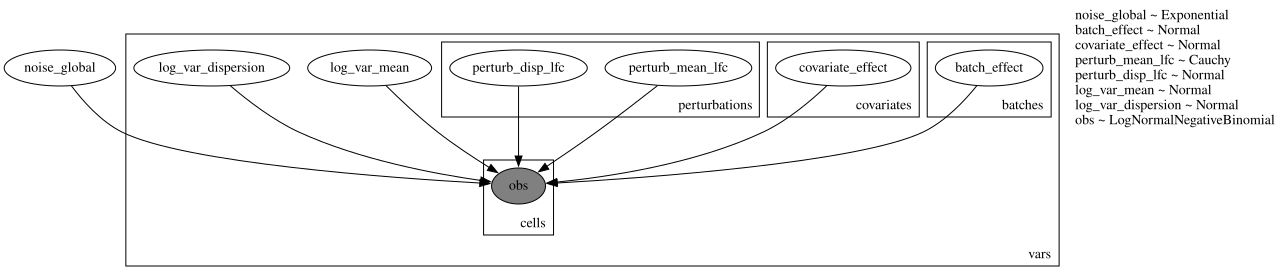

In [10]:
# requires graphviz to be installed
model.render_model()

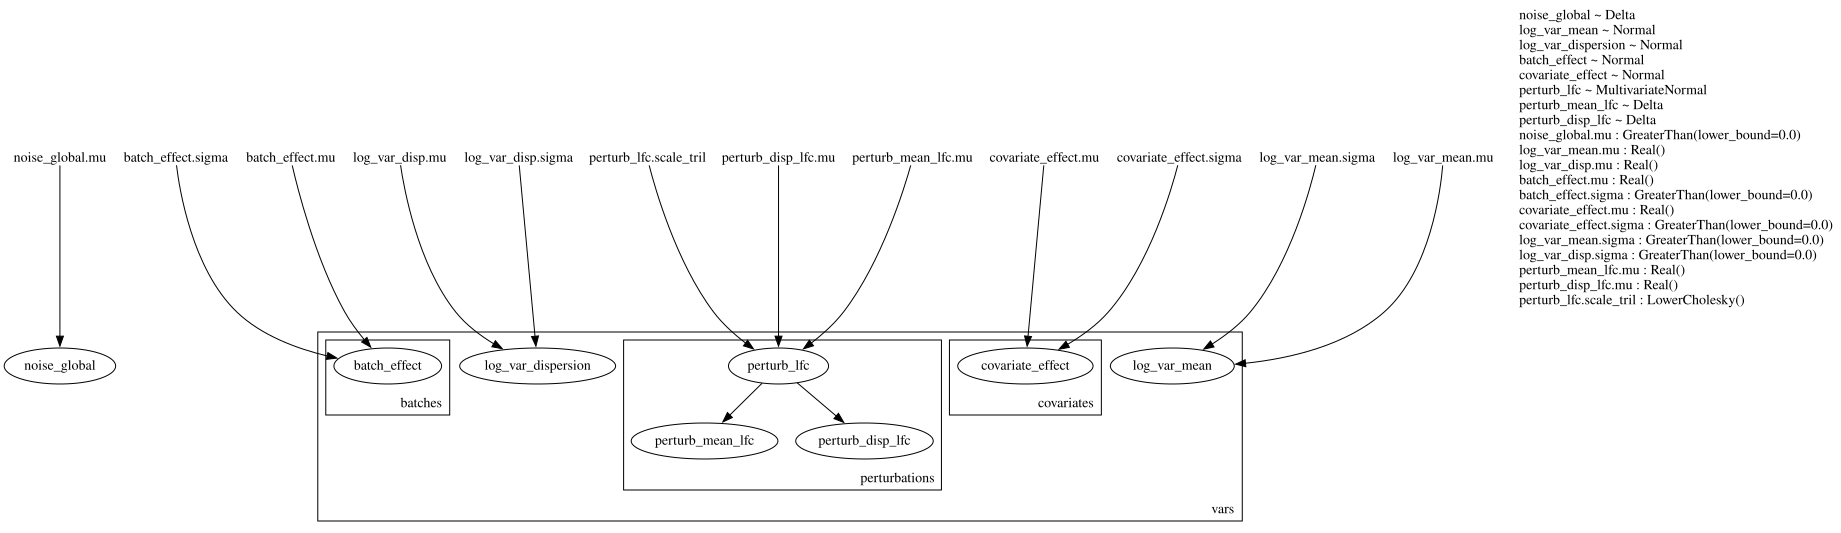

In [11]:
model.render_guide()

## Model training

We can start out with a really high learning rate, then decrease the learning rate to fine-tune


In [12]:
# burn-in
if smoke_test:
    model.train(20, lr=0.1, batch_size=1024)
else:
    model.train(20, lr=0.1, batch_size=4096)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 20/20: 100%|██████████| 20/20 [00:11<00:00,  1.73it/s, v_num=1, elbo_train=4.33e+5]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [00:11<00:00,  1.70it/s, v_num=1, elbo_train=4.33e+5]


In [13]:
# fine-tuning
model.train(50, lr=0.01, batch_size=8192)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/trainer.py:1609: PossibleUserWarning: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower 

Epoch 50/50: 100%|██████████| 50/50 [00:13<00:00,  3.71it/s, v_num=1, elbo_train=4.09e+5]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [00:13<00:00,  3.79it/s, v_num=1, elbo_train=4.09e+5]


In [14]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)


noise_global.mu torch.Size([])
tensor(0.3384, grad_fn=<AddBackward0>)
log_var_mean.mu torch.Size([3])
log_var_disp.mu torch.Size([3])
batch_effect.mu torch.Size([6, 3])
batch_effect.sigma torch.Size([6, 3])
covariate_effect.mu torch.Size([2, 3])
covariate_effect.sigma torch.Size([2, 3])
log_var_mean.sigma torch.Size([3])
log_var_disp.sigma torch.Size([3])
perturb_mean_lfc.mu torch.Size([1243, 3])
perturb_disp_lfc.mu torch.Size([1243, 3])
perturb_lfc.scale_tril torch.Size([1243, 3, 2, 2])


In [15]:
print(pyro.get_param_store()['covariate_effect.mu'])
print(pyro.get_param_store()['covariate_effect.sigma'])


tensor([[ -9.8973, -12.4779, -11.6976],
        [ -0.1078,  -0.1406,  -0.1387]], requires_grad=True)
tensor([[0.0526, 0.0927, 0.0612],
        [0.0012, 0.0018, 0.0014]], grad_fn=<AddBackward0>)


In [16]:
# plt.hist(pyro.get_param_store()["library_size_effect.mu"].cpu().detach().numpy())


In [17]:
%load_ext autoreload
%autoreload 2

# lfc_threshold = -0.1 # ~ at least 10% upreg
lfc_threshold = 0 # nonzero knockdown
# gene_index=45

# scale_factor = 0.01
perturb_mean_lfc_mu = pyro.get_param_store()['perturb_mean_lfc.mu'].detach().cpu().numpy()
perturb_disp_lfc_mu = pyro.get_param_store()['perturb_disp_lfc.mu'].detach().cpu().numpy()
lfc_cov_tril = pyro.get_param_store()['perturb_lfc.scale_tril']
lfc_cov = lfc_cov_tril @ lfc_cov_tril.transpose(dim0=-1, dim1=-2)
perturb_mean_lfc_sigma = lfc_cov[...,0,0].sqrt().detach().cpu().numpy()
perturb_disp_lfc_sigma = lfc_cov[...,1,1].sqrt().detach().cpu().numpy()
assert perturb_mean_lfc_mu.shape == perturb_mean_lfc_sigma.shape
perturb_z_scores = perturb_mean_lfc_mu/perturb_mean_lfc_sigma
perturb_p_vals = norm.sf(lfc_threshold, loc=perturb_mean_lfc_mu, scale=perturb_mean_lfc_sigma)

def make_long_df(mat, value_name):
    return (
        pd.DataFrame(data=mat, columns=selected_genes, index=selected_guides)
        .melt(var_name="gene", value_name=value_name, ignore_index=False)
        .reset_index(names="guide")
        .assign(is_target=lambda x: x['guide'].str.split('_', expand=True)[0]==x['gene'])
    )
mu_df = make_long_df(perturb_mean_lfc_mu, "mu")
z_df = make_long_df(perturb_z_scores, "z_value")
p_df = make_long_df(perturb_p_vals, "p_value")


In [18]:

scpower_df = pd.merge(z_df, p_df)
if not smoke_test:
    scpower_df.to_csv("~/Downloads/all_results.csv")
# significant_results = scpower_df.query("p_value < 1e-8")
# significant_results['element'] = significant_results['guide'].str.split("|", expand=True)[0]
# significant_results
scpower_df.sort_values("p_value").head(10)

# guide_gene_pairs = significant_results.groupby(['element','gene'])['guide'].count()
# guide_gene_pairs=guide_gene_pairs[guide_gene_pairs==2]
# guide_gene_pairs.to_excel("~/Downloads/guide_pairs.xlsx")
# # guide_gene_pairs.index
# scpower_df.query("p_value < 1e-3").to_excel("~/Downloads/significant_results.xlsx")
# significant_results['guide'].str.split("_", expand=True)[0]
# significant_results.head(1000).to_excel("~/Downloads/significant_results.xlsx")

,guide,gene,z_value,is_target,p_value
2765,KRT18_TSS|2,KRT18,-23.418657,True,1.379546e-121
0,ACTB_TSS|1,ACTB,-22.041473,True,5.766142e-108
2764,KRT18_TSS|1,KRT18,-21.037323,True,1.493879e-98
1,ACTB_TSS|2,ACTB,-18.218962,True,1.825077e-74
1245,ACTG1_TSS|1,ACTG1,-17.592262,True,1.411880e-69
1246,ACTG1_TSS|2,ACTG1,-9.796752,True,5.813206e-23
2624,DDX3X_TSS|1,KRT18,-8.865977,False,3.791797e-19
220,GNB2_TSS|1,ACTB,-5.409504,False,3.159978e-08
183,ELAVL1_TSS|2,ACTB,-4.530912,False,2.936481e-06
164,EIF3A_TSS|1,ACTB,-4.474136,False,3.836039e-06


[]

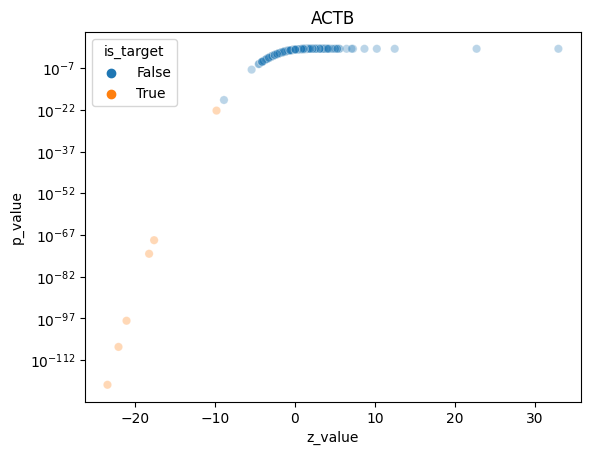

In [19]:
sns.scatterplot(
    scpower_df,
    hue="is_target",
    x="z_value",
    y="p_value",
    alpha=0.3
)
if smoke_test:
    plt.title(selected_genes[0])

plt.semilogy()
# significant_results.groupby("guide").count()['gene'].sort_values().tail(20)
# significant_results.to_excel("significant_results.xlsx")
# # perturb_z_scores[:,gene_index].detach().cpu().numpy()
# z_df = pd.DataFrame({'z_score': perturb_z_scores[:,gene_index],
#                     'mean_mu': perturb_mean_lfc_mu[:,gene_index],
#                     'disp_mu': perturb_disp_lfc_mu[:,gene_index],
#                     'mu_p_val': perturb_p_vals[:,gene_index],
#                     'grna': mdata_subset['grna'].var_names,})
# # z_df.hist('mu_p_val', bins=100)
# names[gene_index])
# print(z_df.sort_values('mu_p_val', ascending=True).reset_index(drop=True).head(20))


In [20]:
import matplotlib.pyplot as plt

# plt.scatter(pyro.get_param_store()["log_var_mean.mu"].cpu().detach().numpy(), pyro.get_param_store()["log_var_disp.mu"].cpu().detach().numpy(), alpha=0.1)


## Compare to SCEPTRE results


In [21]:
# merge_df=merge_df.assign(residual = lambda x: x['z_value']-x['value'])
# merge_df.sort_values('residual').tail(20)


[]

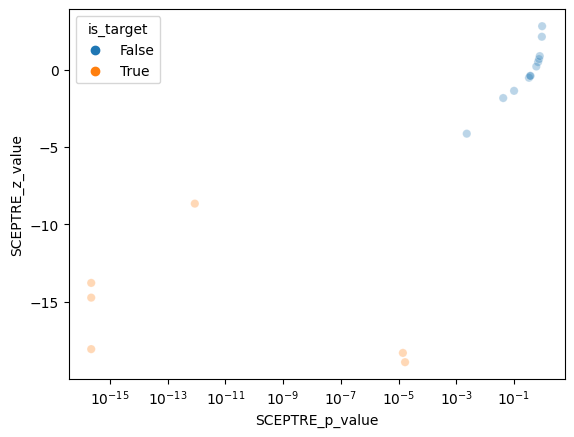

In [22]:
import matplotlib.pyplot as plt

merge_df = pd.merge(sceptre_df, scpower_df, how="inner")

sns.scatterplot(merge_df, x="SCEPTRE_p_value", y="SCEPTRE_z_value", hue="is_target", alpha=0.3)
plt.semilogx()

# plt.xlim([-40, 20])
# plt.ylim([-40, 20])

<Axes: xlabel='z_value', ylabel='SCEPTRE_z_value'>

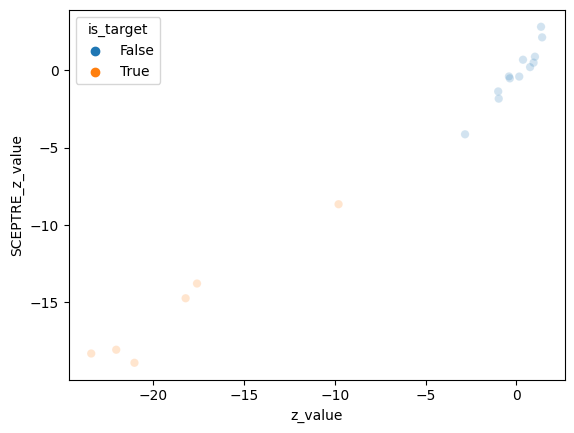

In [23]:
sns.scatterplot(merge_df, x="z_value", y="SCEPTRE_z_value", hue="is_target", alpha=0.2)


[]

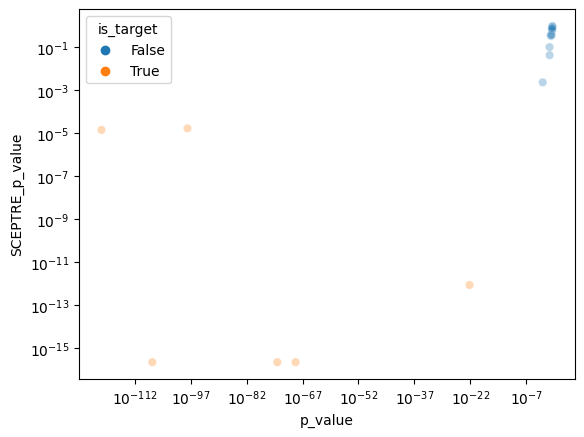

In [24]:
sns.scatterplot(merge_df, x="p_value", y="SCEPTRE_p_value", hue="is_target", alpha=0.3)
plt.loglog()
# plt.xlim(1e-20, 2)
# plt.ylim(1e-20, 2)

plot some genes


2765     KRT18_TSS|2
0         ACTB_TSS|1
2764     KRT18_TSS|1
1         ACTB_TSS|2
1245     ACTG1_TSS|1
1246     ACTG1_TSS|2
2624     DDX3X_TSS|1
220       GNB2_TSS|1
183     ELAVL1_TSS|2
164      EIF3A_TSS|1
Name: guide, dtype: object
ACTB KRT18_TSS|2


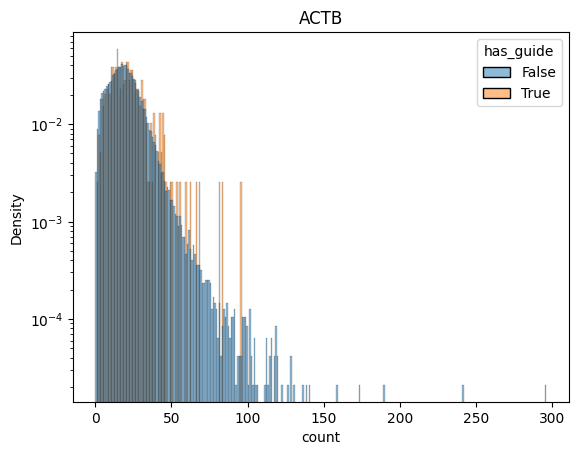

ACTB ACTB_TSS|1


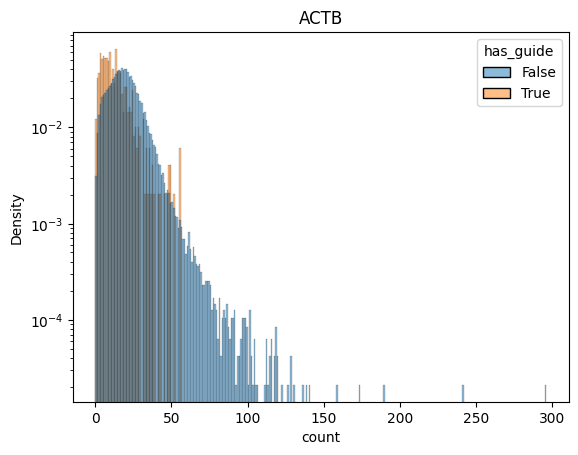

ACTB KRT18_TSS|1


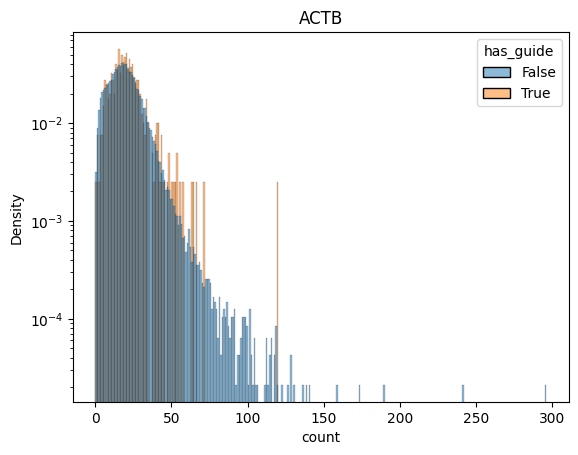

ACTB ACTB_TSS|2


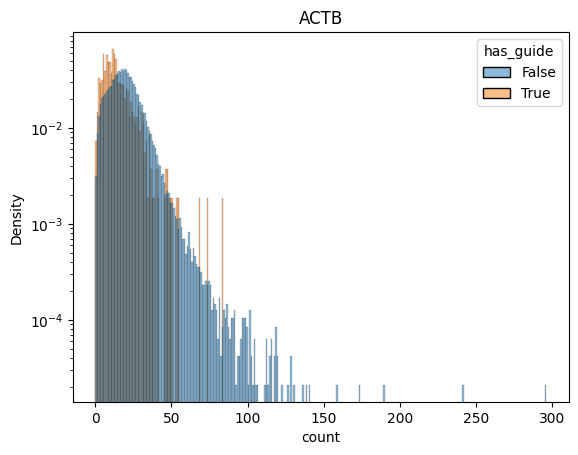

ACTB ACTG1_TSS|1


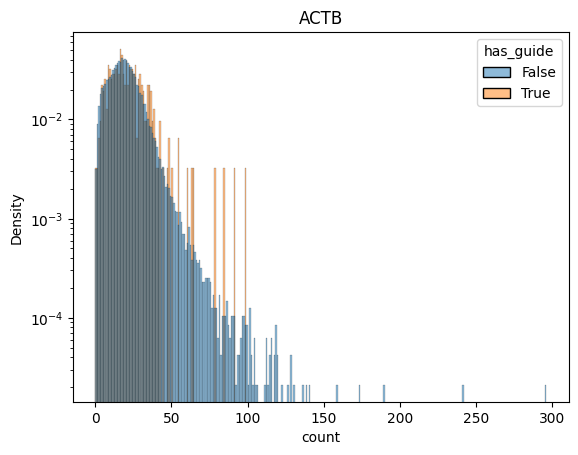

ACTB ACTG1_TSS|2


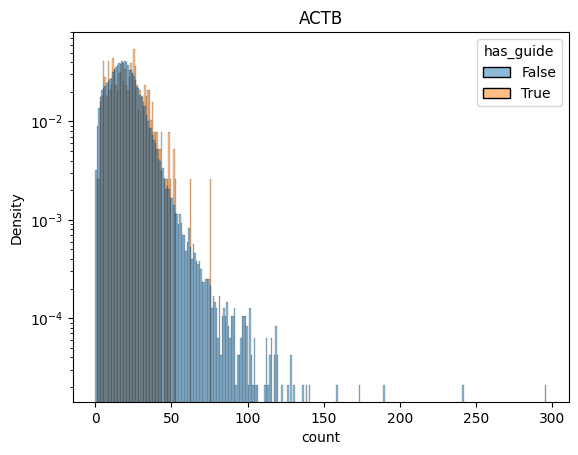

ACTB DDX3X_TSS|1


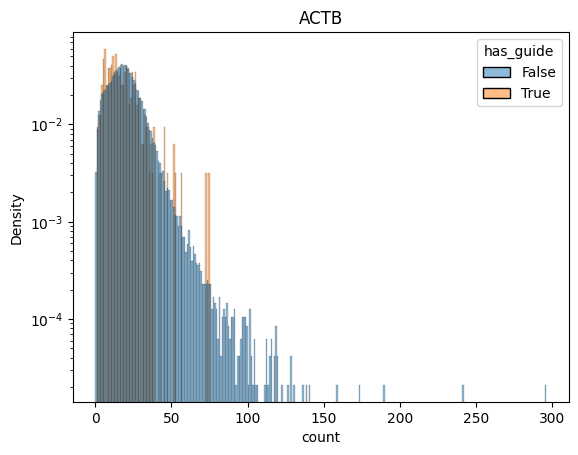

ACTB GNB2_TSS|1


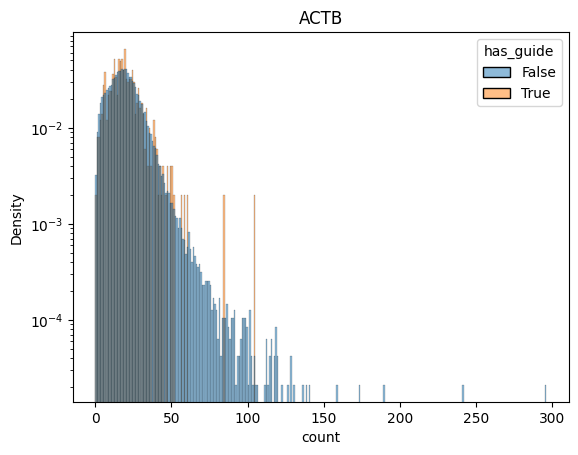

ACTB ELAVL1_TSS|2


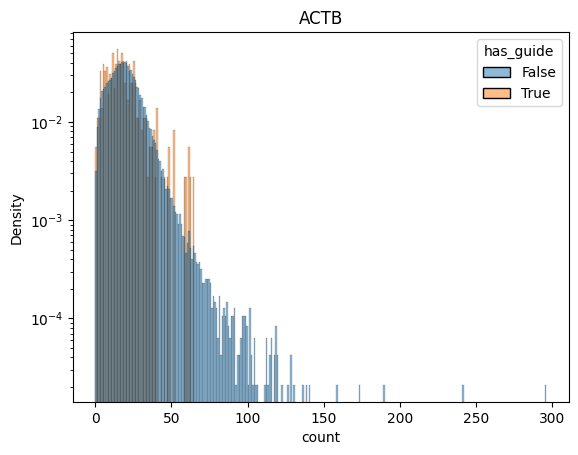

ACTB EIF3A_TSS|1


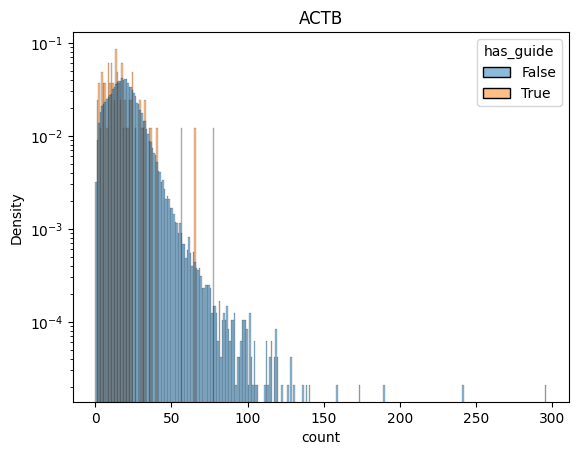

In [25]:
import scanpy as sc

# guide_1 = f"{plot_gene}_TSS|1"
# guide_2 = f"{plot_gene}_TSS|2"
# guide_1 = "TMED10_TSS|1"
# guide_2 = "TMED10_TSS|2"
plot_genes=[selected_genes[0]]
plot_guides=scpower_df.nsmallest(10, "p_value")['guide']

print(plot_guides)
# plot_genes = selected_genes
# plot_gene = selected_genes
# plot_genes = ["TMED10","KDELR2","KDELR3","SEC13", "YIF1A"]
for plot_gene in plot_genes:
    for plot_guide in plot_guides:
        print(plot_gene, plot_guide)
        counts = mdata["rna"][:, plot_gene].X.todense().A1
        guide_1_obs = mdata["grna"][:, plot_guide].X.astype(bool).squeeze()

        plot_df = pd.DataFrame({"count": counts, "has_guide": guide_1_obs})
        sns.histplot(
            plot_df,
            x="count",
            hue="has_guide",
            binwidth=1,
            common_norm=False,
            stat="density",
            log_scale=[False,True]
        )
        # plt.semilogy()
        # plt.xlim(0, 50)
        plt.title(plot_gene)
        plt.show()


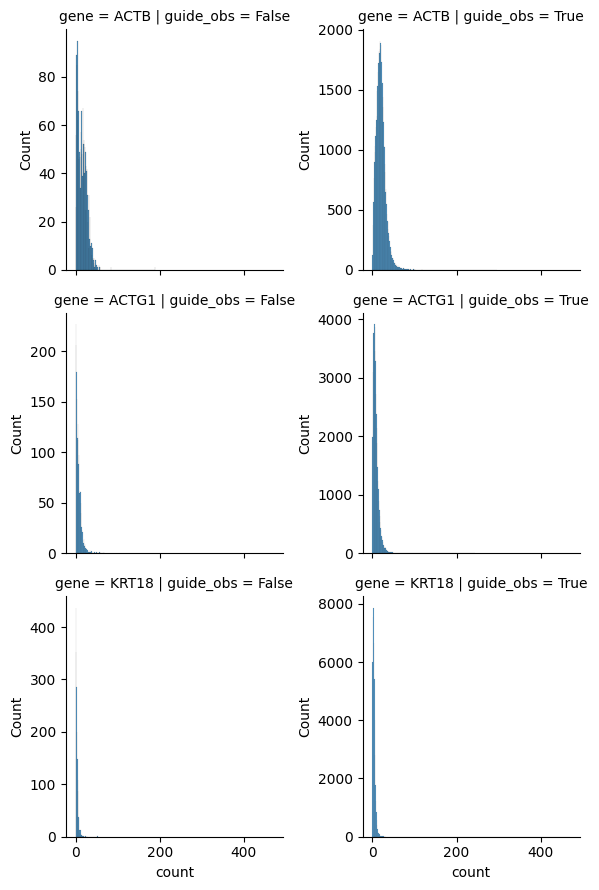

In [26]:
counts_df = mdata["rna"][:, selected_genes].to_df()
guide_obs = mdata["grna"][:, selected_guides].X.sum(axis=1).copy().astype(bool)
counts_df['guide_obs']=guide_obs


plot_df = counts_df.melt(id_vars='guide_obs',var_name='gene',value_name='count')
g = sns.FacetGrid(plot_df, row="gene", col="guide_obs",sharey=False)
g.map_dataframe(sns.histplot, x="count", binwidth=1, hue_order=[False,True])


# sns.histplot(
#     plot_df.query('has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# plt.show()
# sns.histplot(
#     plot_df.query('not has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# # plt.xlim(0, 50)
# g.title(f"gene: {plot_gene}, guide: {plot_guide}")
# plt.show()



Sampling global variables, sample: 100%|██████████| 9/9 [00:00<00:00, 23.62it/s]
(10, 47964, 3)
Sampling global variables, sample: 100%|██████████| 9/9 [00:00<00:00, 23.67it/s]


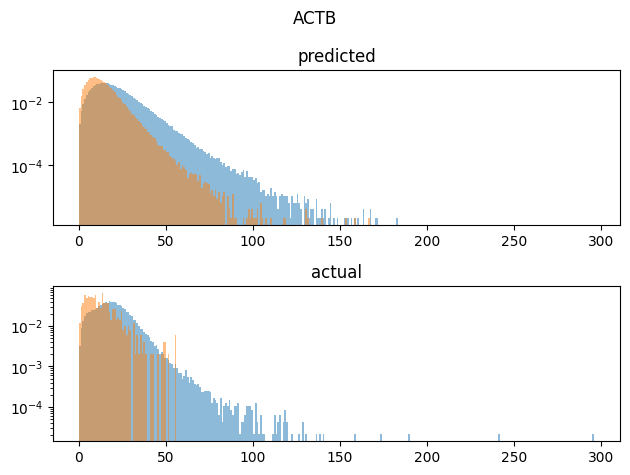

Sampling global variables, sample: 100%|██████████| 9/9 [00:00<00:00, 24.74it/s]


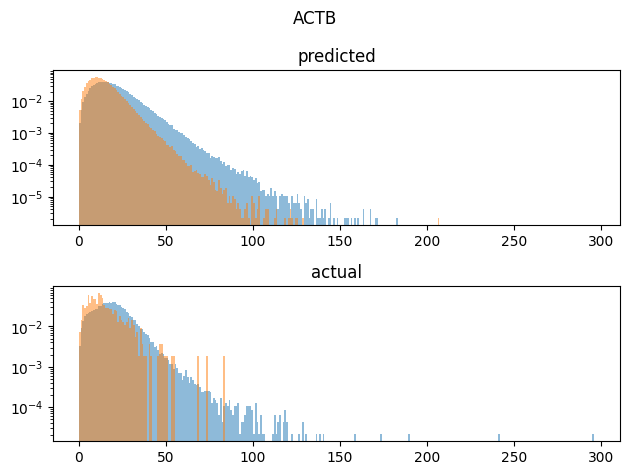

Sampling global variables, sample: 100%|██████████| 9/9 [00:00<00:00, 24.38it/s]


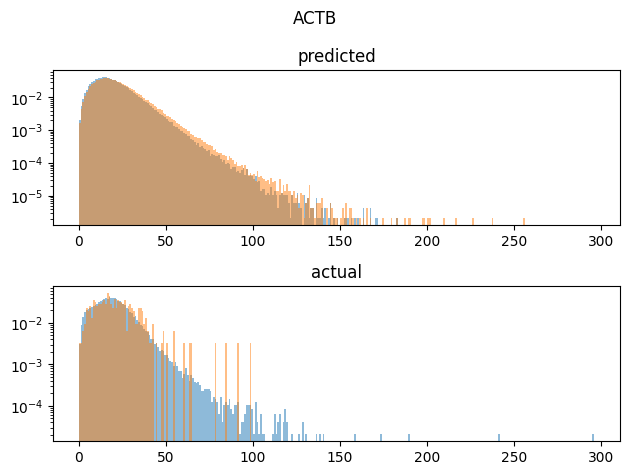

Sampling global variables, sample: 100%|██████████| 9/9 [00:00<00:00, 24.67it/s]


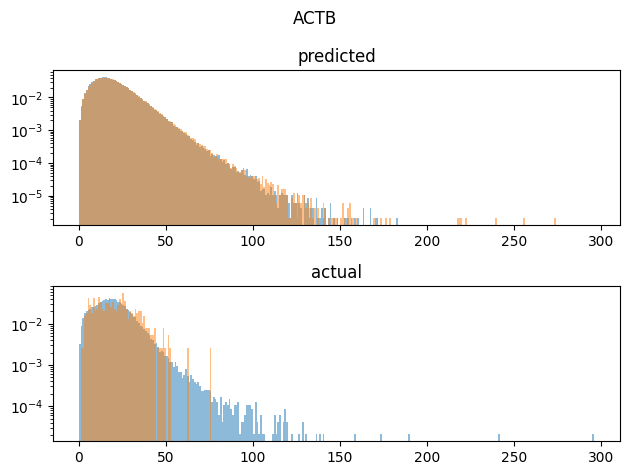

Sampling global variables, sample: 100%|██████████| 9/9 [00:00<00:00, 25.34it/s]


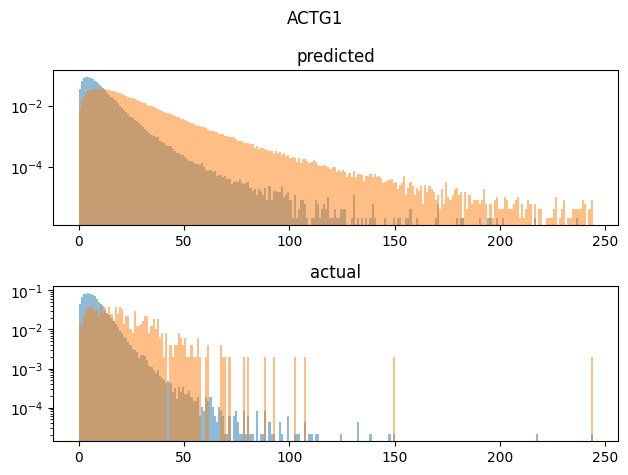

Sampling global variables, sample: 100%|██████████| 9/9 [00:00<00:00, 25.84it/s]


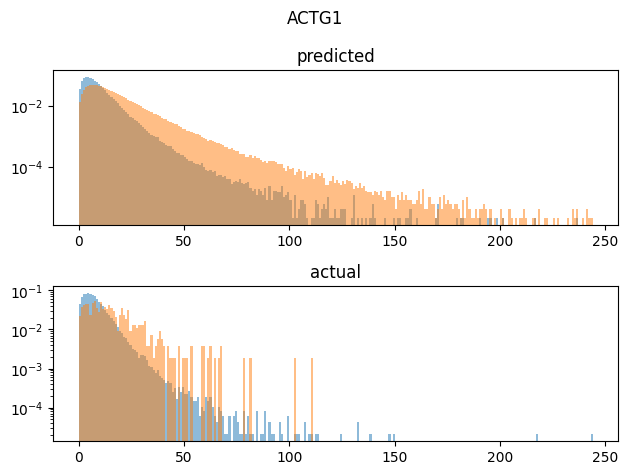

Sampling global variables, sample: 100%|██████████| 9/9 [00:00<00:00, 25.10it/s]


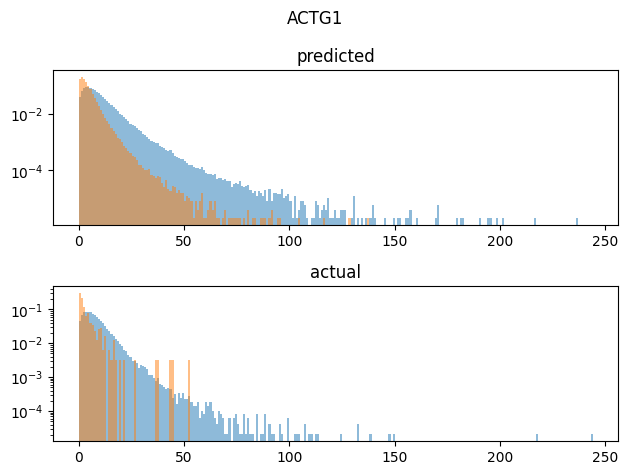

Sampling global variables, sample: 100%|██████████| 9/9 [00:00<00:00, 25.19it/s]


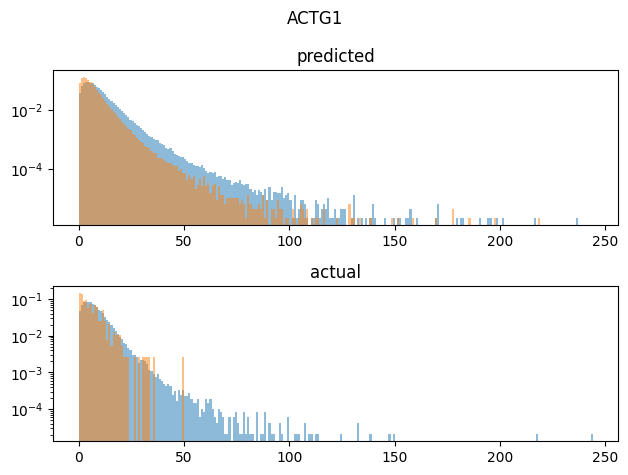

Sampling global variables, sample: 100%|██████████| 9/9 [00:00<00:00, 25.69it/s]


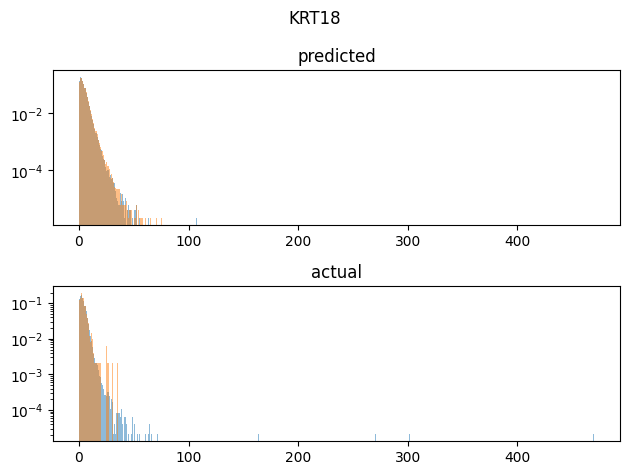

Sampling global variables, sample: 100%|██████████| 9/9 [00:00<00:00, 24.07it/s]


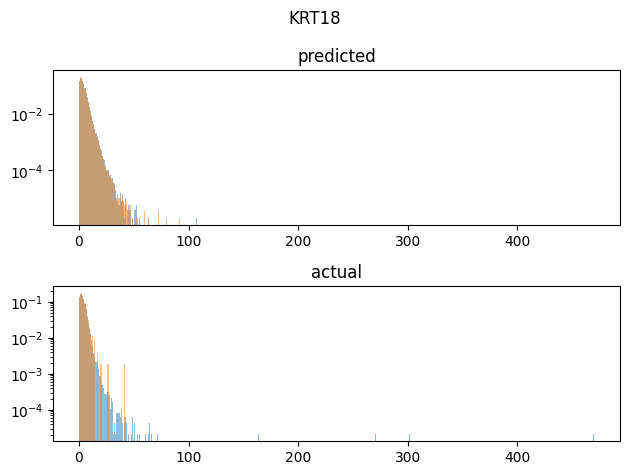

Sampling global variables, sample: 100%|██████████| 9/9 [00:00<00:00, 26.32it/s]


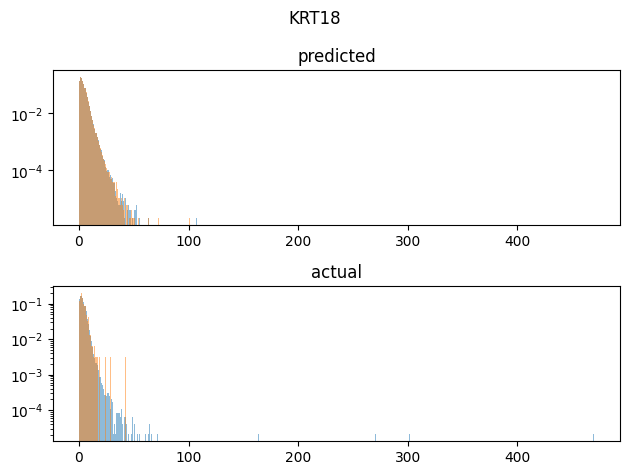

Sampling global variables, sample: 100%|██████████| 9/9 [00:00<00:00, 25.59it/s]


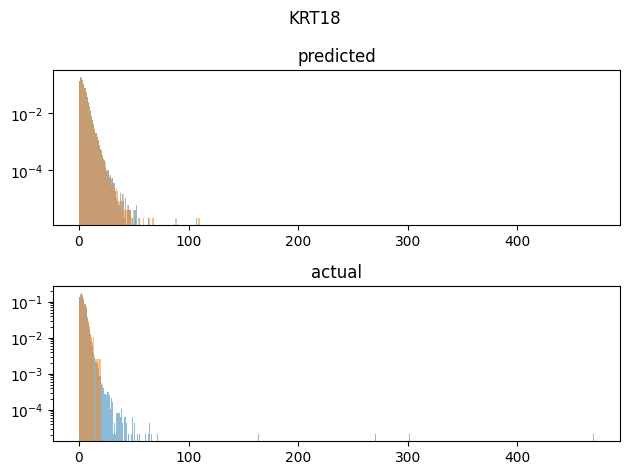

In [27]:
posterior_predictive_samples = model.get_posterior_samples(num_samples=10)['obs']

print(posterior_predictive_samples.shape)
for i in range(min(4, mdata['rna'].n_vars)):
    for j in range(4):
        fig, (ax1, ax2) = plt.subplots(2)
        mdata_subset = mdata[mdata['grna'][:,j].X>0]
        posterior_cond_samples = model.get_posterior_conditional_samples([j],num_samples=10)['obs']
        gene_guide_samples = posterior_cond_samples[..., i].ravel()
        gene_samples = posterior_predictive_samples[..., i].ravel()
        obs_data = mdata['rna'].X[:, i].todense()
        obs_guide_data = mdata_subset['rna'].X[:, i].todense()
        max_bin = max(max(obs_data), max(obs_data))+1
        ax1.set_title('predicted')
        ax1.hist(gene_samples, bins=np.arange(max_bin), density=True, alpha=0.5)
        ax1.hist(gene_guide_samples, bins=np.arange(max_bin), density=True, alpha=0.5)
        ax2.set_title('actual')
        ax2.hist(obs_data, bins=np.arange(max_bin), density=True, alpha=0.5)
        ax2.hist(obs_guide_data, bins=np.arange(max_bin), density=True, alpha=0.5)
        fig.suptitle(mdata['rna'].var_names[i])
        ax1.set_yscale('log')
        ax2.set_yscale('log')
        plt.tight_layout()
        plt.show()

In [28]:
mdata['grna'].var_names

Index(['ACTB_TSS|1', 'ACTB_TSS|2', 'ACTG1_TSS|1', 'ACTG1_TSS|2', 'ACYP1_TSS|1',
       'ACYP1_TSS|2', 'ADIPOR1_TSS|1', 'ADIPOR1_TSS|2', 'ALDH1A2_TSS|1',
       'ALDH1A2_TSS|2',
       ...
       'scrambled_5|1', 'scrambled_5|2', 'scrambled_6|1', 'scrambled_6|2',
       'scrambled_7|1', 'scrambled_7|2', 'scrambled_8|1', 'scrambled_8|2',
       'scrambled_9|1', 'scrambled_9|2'],
      dtype='object', length=1243)